# MOE steel NPV simulation

Run the Monte Carlo simulation for molten oxide electrolysis steel and visualize its total NPV, LNM, and LCOS (steel LCOX) distributions. The NPV summary also reports the number and share of simulations with non-negative versus negative NPV.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from steel.steel_npv_monte_carlo import (
    DEFAULT_RANDOM_SEED,
    DEFAULT_RETROFIT_BAU_MODE,
    DEFAULT_SAMPLE_SIZE,
    simulate_steel_results,
)

from npv_summary import summarize_metric_signs
from npv_summary_plots import plot_financial_metric_distribution


In [2]:
TECHNOLOGY = "moe"
SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
RANDOM_SEED = DEFAULT_RANDOM_SEED
RETROFIT_BAU_MODE = DEFAULT_RETROFIT_BAU_MODE

results_by_technology = simulate_steel_results(
    sample_size=SAMPLE_SIZE,
    random_seed=RANDOM_SEED,
    technologies=(TECHNOLOGY,),
    retrofit_bau_mode=RETROFIT_BAU_MODE,
)
simulation = results_by_technology[TECHNOLOGY]
results = pd.DataFrame(simulation)
results.head()


,run_id,technology,technology_type,retrofit_bau_mode,annual_output_tcs,lifetime_years,capex_eur_per_tcs,fixed_opex_eur_per_tcs,variable_opex_eur_per_tcs,fuel_type,...,annual_electricity_cost_eur,annual_transport_and_storage_cost_eur,annual_emissions_cost_eur,annual_total_cost_eur,annual_net_cash_flow_eur,npv_eur,discounted_lifetime_output_tcs,present_value_total_cost_eur,lcos_eur_per_tcs,levelized_net_margin_eur_per_tcs
0,0,moe,absolute,not_applicable,1000000.0,20.0,1032.025015,71.257509,221.326208,none,...,4.053839e+08,0.0,0.0,6.979677e+08,-2.479677e+08,-3.466608e+09,9.818147e+06,7.884774e+09,803.081678,-353.081678
1,1,moe,absolute,not_applicable,1000000.0,20.0,1206.249835,48.942045,249.744787,none,...,5.657469e+08,0.0,0.0,8.644337e+08,-4.144337e+08,-5.275221e+09,9.818147e+06,9.693388e+09,987.292954,-537.292954
2,2,moe,absolute,not_applicable,1000000.0,20.0,824.411672,87.816367,251.560532,none,...,7.303346e+08,0.0,0.0,1.069711e+09,-6.197115e+08,-6.908830e+09,9.818147e+06,1.132700e+10,1153.679613,-703.679613
3,3,moe,absolute,not_applicable,1000000.0,20.0,869.173442,92.289898,210.174253,none,...,7.696020e+08,0.0,0.0,1.072066e+09,-6.220661e+08,-6.976710e+09,9.818147e+06,1.139488e+10,1160.593347,-710.593347
4,4,moe,absolute,not_applicable,1000000.0,20.0,1598.963868,60.212535,317.585184,none,...,6.831731e+08,0.0,0.0,1.060971e+09,-6.109709e+08,-7.597566e+09,9.818147e+06,1.201573e+10,1223.828865,-773.828865


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
lcos_eur_per_tcs = results["lcos_eur_per_tcs"]
levelized_net_margin_eur_per_tcs = results["levelized_net_margin_eur_per_tcs"]

summary = pd.concat(
    [
        npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR"
        ),
        lcos_eur_per_tcs.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "LCOS EUR/tCS"
        ),
        levelized_net_margin_eur_per_tcs.describe(
            percentiles=[0.05, 0.5, 0.95]
        ).rename("Levelized net margin EUR/tCS"),
    ],
    axis=1,
)

npv_signs = summarize_metric_signs(npv_million_eur)
npv_sign_summary = pd.DataFrame(
    {
        "NPV category": ["Non-negative (NPV >= 0)", "Negative (NPV < 0)"],
        "Simulation count": [
            npv_signs["non_negative_count"],
            npv_signs["negative_count"],
        ],
        "Simulation share": [
            npv_signs["non_negative_share"],
            1.0 - npv_signs["non_negative_share"],
        ],
    }
)

display(summary)
display(npv_sign_summary)


,NPV million EUR,LCOS EUR/tCS,Levelized net margin EUR/tCS
count,100000.000000,100000.000000,100000.000000
mean,-6845.764242,1147.256209,-697.256209
std,1583.455706,161.278461,161.278461
min,-11953.945585,568.398999,-1217.535762
5%,-9353.356355,872.904274,-952.660005
50%,-6901.509210,1152.933957,-702.933957
95%,-4152.136506,1402.660005,-422.904274
max,-1162.458821,1667.535762,-118.398999


,NPV category,Simulation count,Simulation share
0,Non-negative (NPV >= 0),0,0.0
1,Negative (NPV < 0),100000,1.0


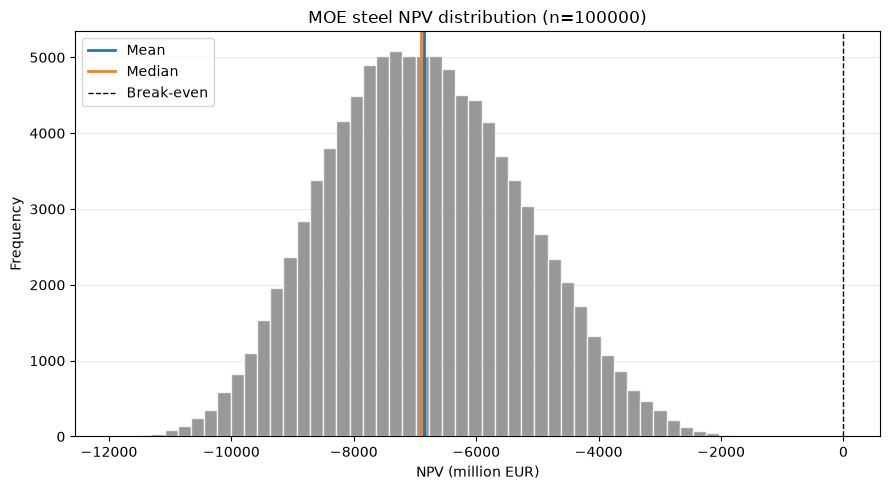

In [4]:
plot_financial_metric_distribution(
    npv_million_eur,
    title=f"MOE steel NPV distribution (n={SAMPLE_SIZE})",
    x_axis_label="NPV (million EUR)",
    color="tab:gray",
    show_break_even=True,
)
plt.show()


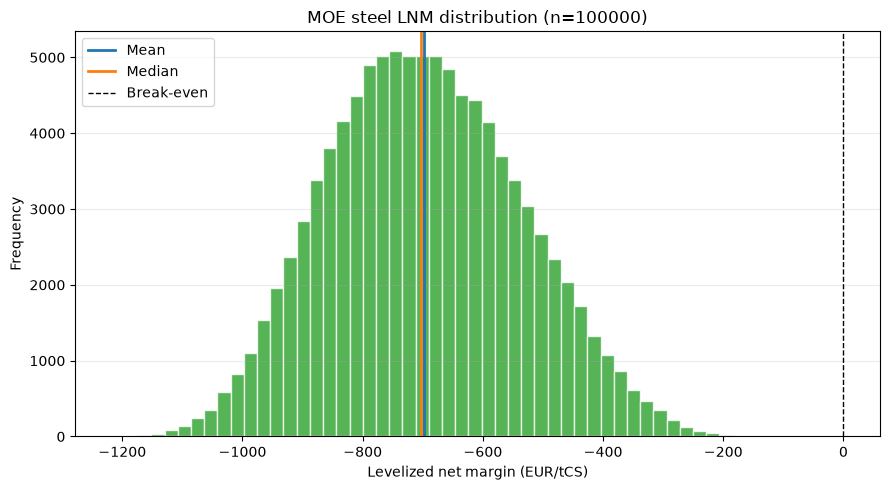

In [5]:
plot_financial_metric_distribution(
    levelized_net_margin_eur_per_tcs,
    title=f"MOE steel LNM distribution (n={SAMPLE_SIZE})",
    x_axis_label="Levelized net margin (EUR/tCS)",
    color="tab:green",
    show_break_even=True,
)
plt.show()


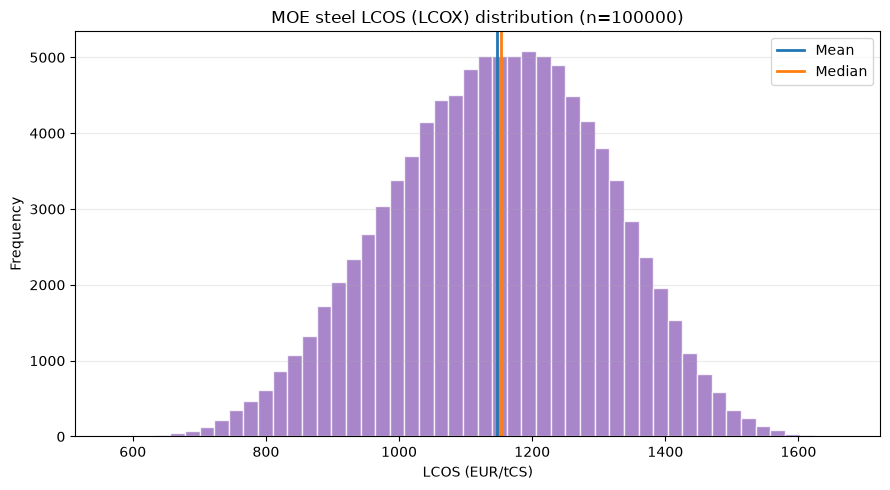

In [6]:
plot_financial_metric_distribution(
    lcos_eur_per_tcs,
    title=f"MOE steel LCOS (LCOX) distribution (n={SAMPLE_SIZE})",
    x_axis_label="LCOS (EUR/tCS)",
    color="tab:purple",
)
plt.show()


In [7]:
annual_components = results[
    [
        "annual_revenue_eur",
        "annual_fixed_opex_eur",
        "annual_variable_opex_eur",
        "annual_fuel_cost_eur",
        "annual_electricity_cost_eur",
        "annual_emissions_cost_eur",
        "annual_net_cash_flow_eur"
    ]
] / 1_000_000

annual_components.mean().rename("Mean annual value, million EUR")


annual_revenue_eur             450.000000
annual_fixed_opex_eur           69.014904
annual_variable_opex_eur       246.046319
annual_fuel_cost_eur             0.000000
annual_electricity_cost_eur    713.340818
annual_emissions_cost_eur        0.000000
annual_net_cash_flow_eur      -578.402041
Name: Mean annual value, million EUR, dtype: float64